In [1]:
from firedrake import *
import numpy as np

# Problem set-up

## Define the simulation domain and entities

In [459]:
"""Define the simulation domain and the particles within it"""
nx, ny = 2, 2
mesh = UnitSquareMesh(nx,ny)
dim = mesh.geometric_dimension
mesh_coords = mesh.coordinates

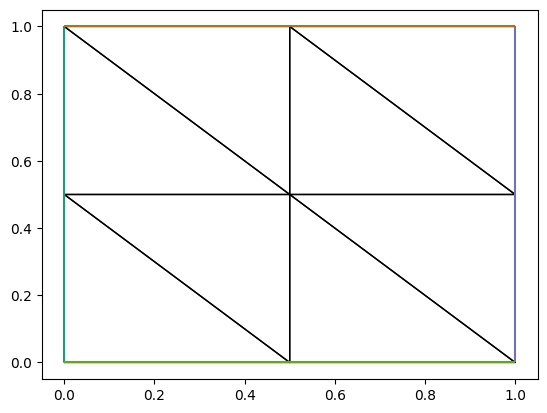

In [461]:
%matplotlib inline    
triplot(mesh)
plt.show()

In [462]:
coords = mesh_coords.dat.data_ro
cells = mesh_coords.cell_node_map().values

for square_idx in range(nx * ny):
    tri0 = coords[cells[2 * square_idx]]
    tri1 = coords[cells[2 * square_idx + 1]]
    print(f"Square {square_idx}:")
    print("  cell0 vertices:", tri0)
    print("  cell1 vertices:", tri1)
    print()

Square 0:
  cell0 vertices: [[0.  0. ]
 [0.  0.5]
 [0.5 0. ]]
  cell1 vertices: [[0.  0.5]
 [0.5 0. ]
 [0.5 0.5]]

Square 1:
  cell0 vertices: [[0.5 0. ]
 [0.5 0.5]
 [1.  0. ]]
  cell1 vertices: [[0.  0.5]
 [0.5 0.5]
 [0.  1. ]]

Square 2:
  cell0 vertices: [[0.5 0.5]
 [1.  0. ]
 [1.  0.5]]
  cell1 vertices: [[0.5 0.5]
 [0.  1. ]
 [0.5 1. ]]

Square 3:
  cell0 vertices: [[0.5 0.5]
 [1.  0.5]
 [0.5 1. ]]
  cell1 vertices: [[1.  0.5]
 [0.5 1. ]
 [1.  1. ]]



In [537]:
N = 10
particle_coords = np.random.rand(N, 2) 

particle_mesh = VertexOnlyMesh(mesh, particle_coords)
particle_mesh_coords = particle_mesh.coordinates # the same as particle_coords, though not in the same order

print(particle_mesh_coords.dat.data_ro)

[[0.06492118 0.42413466]
 [0.25146407 0.0446753 ]
 [0.11635082 0.07319001]
 [0.33781094 0.40867616]
 [0.61603878 0.01447722]
 [0.86744234 0.47707548]
 [0.80875191 0.29624138]
 [0.37720767 0.85571129]
 [0.60234287 0.54616661]
 [0.70424594 0.92614833]]


In [538]:
"""Assign constant velocity to the particles"""

V = VectorFunctionSpace(particle_mesh, "DG", 0, dim=2)
velocity = Function(V)
velocity.dat.data[:] = np.random.normal(0.0, 0.025, size=(N, 2))

# print("Particle velocity: ", velocity.dat.data_ro)

# Move particles in physical space

In [ ]:
"""Move particles in physical space"""

particle_coords_phys = np.copy(particle_coords)

def apply_periodic_bc(coords):
    return np.mod(coords, 1.0) # assuming the domain is [0, 1]x[0, 1]

# Unecessary to reimplement as done by Firedrake mesh.locate_cell_and_reference_coordinate
def is_in_domain(particle_coords):
    outside_x = np.logical_or(particle_coords[:, 0] < 0.0, particle_coords[:, 0] > 1.0)
    outside_y = np.logical_or(particle_coords[:, 1] < 0.0, particle_coords[:, 1] > 1.0)
    outside_any = np.logical_or(outside_x, outside_y)
    idx_outside = np.where(outside_any)[0]
    num_outside = np.count_nonzero(outside_any)

    if num_outside > 0:
        print(f"[t={t:.2f}] {num_outside} particles left the domain.")
        # print(np.where(outside_any)) # print indices
        # print(particle_coords[outside_any]) # print coordinates
    return idx_outside

T = 1.0
dt = 0.1
t = 0.0

# Implement a time stepper that advances the particles in global space
left_phys = np.array([], dtype=int)
while t < T:
    """"
    # Forward Euler update
    particle_mesh.coordinates.interpolate(particle_mesh.coordinates + velocity * dt)

    # 1. Resolve the inconsistencies
    # 2. Forcing term (particles interact with mesh fields)
    # 3. How change of coordinates work in UFL form assembly
    # velocity lives in tangent space so change of coords. is always affine
    # for particle_mesh change of coords: local coord. stored in the mesh object (though not exposed to the user)

    """
    particle_coords_phys += velocity.dat.data_ro * dt
    
    # Apply periodic BC
    # particle_coords = apply_periodic_bc(particle_coords)

    left_now = is_in_domain(particle_coords_phys)

    if left_now.size > 0:
        left_phys = np.unique(np.concatenate([left_phys, left_now]))

    # Update the coordinates of each particle in the vertex-only mesh
    particle_mesh.coordinates.dat.data[:] = particle_coords_phys # this updates the global coordinates of vertex only mesh only
    
    t += dt
    # print(f"t={t:.2f}, first particle pos={particle_coords[0]}")


[t=0.30] 1 particles left the domain.
[t=0.40] 1 particles left the domain.
[t=0.50] 1 particles left the domain.
[t=0.60] 1 particles left the domain.
[t=0.70] 1 particles left the domain.
[t=0.80] 1 particles left the domain.
[t=0.90] 1 particles left the domain.
[t=1.00] 1 particles left the domain.


In [ ]:
F = particle_mesh.coordinates.function_space() # the function space of the vertex-only mesh coordinate field
func = assemble(interpolate(SpatialCoordinate(mesh), F)) # interpolating from global coordinates into the vertex-only mesh coordinate field -> returns 

print(particle_mesh.coordinates.dat.data - func.dat.data)

[[ 0.36411279  0.42731093]
 [ 0.63276204  0.41076759]
 [ 0.46199404  0.46632975]
 [-0.27187634  0.01387977]
 [ 0.06450715 -0.04521728]
 [-0.20431578  0.45145362]
 [-0.43630402  0.08202566]
 [-0.11682649 -0.83404838]
 [ 0.20830123 -0.22579928]
 [-0.56701368 -0.83280889]]


# Move particles in reference space 

## Bin particles to cells and get their coordinates in reference space

1. For each particle, find the cell that contains it.
The only built-in method available in Firedrake that allows to identify the cell to which a given point belongs is `mesh.locate_cell`. PETSc DMPlex offers a point location function `DMPlexLocatePoints` (which `locate_cell` may already use?)

2. Invert the geometric map from the reference element.
Each cell defines a geometric map from the reference cell G: X -> x

In [540]:
"""Build an array of vertex coordinates per cell"""

cell_nodes = mesh_coords.cell_node_map().values # global mesh dofs for each cell
coords = mesh_coords.dat.data_ro # vertex positions
cell_coords = coords[cell_nodes]

# print(cell_coords)

### A custom binning implementation for the UnitSquareMesh

In [541]:
"""Bin particles to their containing cells based on the structure of the unit square mesh"""

# Build a square-to-cell map (stores the cells that each square contains)
hx, hy = 1.0 / nx, 1.0 / ny
square_to_cells = [[] for _ in range(nx * ny)]

for c, tri in enumerate(cell_coords):
    cx, cy = tri[:,0].mean(), tri[:,1].mean()
    i = min(nx-1, max(0, int(cx / hx)))
    j = min(ny-1, max(0, int(cy / hy)))
    square_idx = i + j * nx
    square_to_cells[square_idx].append(c)


def invert_geometric_map(p, tri):
    """
    Args:
        p: the particle's position in global space
        tri: the global coordinates of the triangle

    Returns:
        invJ: inverse of the Jacobian
        [X, Y]: local coordinates
    """
    x1, x2, x3 = tri
    J = np.column_stack((x2 - x1, x3 - x1))
    invJ = np.linalg.inv(J)
    X, Y = invJ @ (p - x1)
    return invJ, np.array([X, Y])

def locate_particles_and_ref_coords(particle_coords, cell_coords, square_to_cells):
    """
    For each particle:
      - find which Firedrake cell (triangle) it lives in
      - compute its reference coordinates (X, Y)
    """
    ref_coords = np.zeros((N, 2))
    cell_indices = np.full(N, -1, dtype=int)

    for k, p in enumerate(particle_coords):
        x, y = p
        i = min(nx - 1, max(0, int(x / hx)))
        j = min(ny - 1, max(0, int(y / hy)))
        square_idx = i + j * nx # index of the square the particle lives in

        cells_in_square = square_to_cells[square_idx] # triangle cells in the containing square
        if len(cells_in_square) != 2:
            raise ValueError(f"Square {square_idx} has {len(cells_in_square)} triangles, expected 2")

        # Compute the local coordinates and barycentric coordinates of the particle in both triangles
        refA = invert_geometric_map(p, cell_coords[cells_in_square[0]])[1]
        baryA = np.array([1 - refA[0] - refA[1], refA[0], refA[1]])

        refB = invert_geometric_map(p, cell_coords[cells_in_square[1]])[1]
        baryB = np.array([1 - refB[0] - refB[1], refB[0], refB[1]])

        # Triangle test:
        # Pick the triangle where all barycentric coords. are non negative
        if (baryA >= -1e-12).all():
            ref_coords[k] = refA
            cell_indices[k] = cells_in_square[0]
        elif (baryB >= -1e-12).all():
            ref_coords[k] = refB
            cell_indices[k] = cells_in_square[1]
        else:
            ref_coords[k] = np.nan
            cell_indices[k] = -1

    return cell_indices, ref_coords

#### Test the correctness of the custom binning implementation

In [542]:
# Test the binning method and mapping to reference space
pts = np.array([[0.1, 0.3], [0.8, 0.9], [0.3, 0.7], [0.8, 0.1]])

cell_indices, ref_coords = locate_particles_and_ref_coords(pts, cell_coords, square_to_cells)
for i in range(len(pts)):
    print("Particle: ", pts[i], "cell: ", cell_indices[i], "ref coords: ", ref_coords[i])

Particle:  [0.1 0.3] cell:  0 ref coords:  [0.6 0.2]
Particle:  [0.8 0.9] cell:  7 ref coords:  [0.4 0.4]
Particle:  [0.3 0.7] cell:  3 ref coords:  [0.6 0.4]
Particle:  [0.8 0.1] cell:  2 ref coords:  [0.2 0.6]


In [543]:
# Use Firedrake's built-in `mesh.locate_cell` to identify which cell the particle lives in
# `mesh.locate_cell` returns the first output of `mesh.locate_cell_and_reference_coordinate` so we call the latter

for p in pts:
    p_cell = mesh.locate_cell_and_reference_coordinate(p)[0]
    p_ref_coord = mesh.locate_cell_and_reference_coordinate(p)[1]
    print("Particle: ", p, "cell: ", p_cell, "ref coords: ", p_ref_coord)

Particle:  [0.1 0.3] cell:  0 ref coords:  [0.6 0.2]
Particle:  [0.8 0.9] cell:  7 ref coords:  [0.4 0.4]
Particle:  [0.3 0.7] cell:  3 ref coords:  [0.6 0.4]
Particle:  [0.8 0.1] cell:  2 ref coords:  [0.2 0.6]


## Project the particles to reference space

In [554]:
# Use the manual 'locate_particles_and_ref_coords' function to get the coordinates of the particles in reference space
particle_cell_indices, particle_coords_ref_locate = locate_particles_and_ref_coords(particle_coords, cell_coords, square_to_cells)
# print(particle_coords_ref_locate)

# Check against Firedrake's built-in `mesh.locate_cell_and_reference_coordinate`
particle_coords_ref_firedrake = np.zeros((N, dim))
for k,p in enumerate(particle_coords):
    particle_coords_ref_firedrake[k, :] = mesh.locate_cell_and_reference_coordinate(p)[1]
# print(particle_coords_ref_firedrake)

assert np.all(particle_coords_ref_locate) == np.all(particle_coords_ref_firedrake)

In [555]:
particle_coords_ref = particle_coords_ref_locate
print(particle_cell_indices) # the indices of the cells to which particle belong
print(particle_coords_ref) # the coordinates of particles in ref space

[5 4 6 0 2 7 1 0 4 0]
[[0.24558465 0.46583793]
 [0.04584904 0.68903564]
 [0.20468573 0.09233321]
 [0.84826932 0.12984235]
 [0.02895444 0.23207756]
 [0.59150812 0.26078855]
 [0.18264769 0.49297419]
 [0.0893506  0.50292814]
 [0.40751725 0.20998657]
 [0.14638002 0.23270163]]


### Update the particle positions in reference space 

Let $x$ be a particle in physical space with coordinate point $X$ in reference space satisfying: 

$$ x = \hat{x_1} + JX $$

where $x_1$ is the global coordinate point of the first vertex (node) of the containing cell.

The inverse map, from physical space to reference space, is therefore:

$$ X = J^{-1}(x - x_1)$$

Taking the derivative, we have: 

$$\dot{X}(t) = J^{-1}\dot{x}(t) = J^{-1}v$$

where $v$ is the velocity vector (assumed constant in this example).

One forward Euler step in reference space is therefore:

$$X(t+\Delta t) = X(t) + J^{-1}v\Delta t$$


In [556]:
"""Move particles in reference space"""
T = 1.0
dt = 0.1
t = 0.0

active = np.ones(N, dtype=bool) # track active particles (where active means that particles are within the domain boundaries)

# Implement a time stepper that advances particles in ref. space
while t < T:
    for p in range(N):
        if not active[p]:
            continue # skip inactive particles

        c_p = particle_cell_indices[p] # the Firedrake cell the particle lives in
        # print(f"Particle {particle_coords[p]}, cell: {c_p}")

        if c_p < 0:
            active[p] = False # mark as inactive
            continue

        tri_p = cell_coords[c_p] # the coords of the containing cell
        invJ = invert_geometric_map(particle_coords[p],tri)[0]

        v_p_phys = velocity.dat.data_ro[p]
        v_p_ref = invJ @ v_p_phys # J^{-1}v
        # print(f"Particle {particle_coords[p]}, ref velocity: {v_p_ref}")

        particle_coords_ref[p] += v_p_ref * dt # update ref coords.

        # Check if a particle left the ref. triangle
        X_p, Y_p = particle_coords_ref[p]
        if (X_p <= 1e-12) or (Y_p <= 1e-12) or (X_p + Y_p >= 1 + 1e-12):
            active[p] = False # mark as inactive

    t += dt

In [558]:
# Inspect which particles are still in the reference cell and which have left after integration
in_ref = np.where(active)[0]
left_ref = np.where(~active)[0]
print(f"{len(left_ref)} particles left the reference domain.")

# Compare who left the physical domain vs who left the ref domain
print('\n')
print("Indices of particles that left the physical domain:", left_phys)
print("Indices of particles that left the reference cell:", left_ref)

1 particles left the reference domain.


Indices of particles that left the physical domain: [4]
Indices of particles that left the reference cell: [4]


# Comparing integration in physical and reference space

Given that our mesh is affine (i.e., the projection into the ref. space is merely a shift and a scaling of coords) and the per-particle velocities are constant, integrating in reference space should match integrating in physical space (up to round-off error) **as long as the particle stays within its initial cell**. This requirement amounts to considering only the particles that are "active" at the end of the integration period and comparing their corresponding physical location.

In [559]:
# Map the final reference positions back to global space for the active set only
particle_coords_from_ref = np.empty_like(particle_coords_phys)
for p in range(N):
    c = particle_cell_indices[p]
    # if particle left its cell, put NaNs (ignored in error)
    if (not active[k]) or (c < 0):
        particle_coords_from_ref[p] = np.nan
        continue
    X_p, Y_p = particle_coords_ref[p]
    Phi = np.array([1.0 - X_p - Y_p, X_p, Y_p]) # basis functions
    particle_coords_from_ref[p] = Phi @ cell_coords[c]  # = x1 + J @ [X_p, Y_p]

In [560]:
errs = np.linalg.norm(particle_coords_from_ref[active] - particle_coords_phys[active], axis=1)
print(errs)

[3.55444798e-16 5.43289380e-02 5.36611735e-02 1.67689008e-03
 3.33066907e-16 9.19890363e-02 2.69860488e-02 3.14432943e-02
 4.57114016e-02]
